# 🔍 Comparative Analysis: Phisher vs Normal Accounts

## Objective
This notebook performs detailed comparative analysis between phisher and normal Ethereum accounts to identify distinguishing patterns and characteristics:
- Transaction volume and frequency differences
- Transaction amount patterns
- Incoming vs outgoing transaction ratios
- Temporal behavior patterns

---

## 1. Setup and Import Libraries

In [1]:
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from process_data.utils import load_pkl, load_txt
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Visualization settings
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load Data

In [2]:
# Load processed data
eoa2seq = load_pkl('../process_data/eoa2seq.pkl')
phisher_list = load_txt('../Datas/phisher_accounts.txt')

print(f"✅ Loaded {len(eoa2seq):,} accounts")
print(f"✅ Loaded {len(phisher_list):,} phisher accounts")

# Convert phisher list to set for faster lookup
phisher_set = set(phisher_list)

✅ Loaded 10,960 accounts
✅ Loaded 5,480 phisher accounts


## 3. Extract Features for Both Groups

In [3]:
def extract_account_features(address, transactions):
    """Extract comprehensive features from account transactions"""
    if len(transactions) == 0:
        return None
    
    # Basic counts
    total_txs = len(transactions)
    in_txs = sum(1 for tx in transactions if tx[3] == 'IN')
    out_txs = total_txs - in_txs
    
    # Amounts (convert to float)
    amounts = [float(tx[2]) for tx in transactions]
    in_amounts = [float(tx[2]) for tx in transactions if tx[3] == 'IN']
    out_amounts = [float(tx[2]) for tx in transactions if tx[3] == 'OUT']
    
    # Temporal features
    timestamps = [int(tx[1]) for tx in transactions]
    time_span = max(timestamps) - min(timestamps) if len(timestamps) > 1 else 0
    
    return {
        'address': address,
        'total_transactions': total_txs,
        'in_transactions': in_txs,
        'out_transactions': out_txs,
        'in_out_ratio': in_txs / out_txs if out_txs > 0 else 0,
        'total_amount': sum(amounts),
        'avg_amount': np.mean(amounts),
        'median_amount': np.median(amounts),
        'std_amount': np.std(amounts),
        'min_amount': min(amounts),
        'max_amount': max(amounts),
        'avg_in_amount': np.mean(in_amounts) if in_amounts else 0,
        'avg_out_amount': np.mean(out_amounts) if out_amounts else 0,
        'time_span_seconds': time_span,
        'time_span_days': time_span / 86400 if time_span > 0 else 0,
        'tx_per_day': total_txs / (time_span / 86400) if time_span > 0 else 0,
        'unique_counterparties': len(set(tx[0] for tx in transactions))
    }

print("🔄 Extracting features for all accounts...")

# Extract features for phisher accounts
phisher_features = []
for addr in phisher_list:
    if addr in eoa2seq:
        features = extract_account_features(addr, eoa2seq[addr])
        if features:
            phisher_features.append(features)

# Extract features for normal accounts (sample if too many)
normal_addresses = [addr for addr in eoa2seq.keys() if addr not in phisher_set]
sample_size = min(len(phisher_features) * 2, len(normal_addresses))  # Sample 2x phisher size or all
normal_sample = np.random.choice(normal_addresses, sample_size, replace=False)

normal_features = []
for addr in normal_sample:
    features = extract_account_features(addr, eoa2seq[addr])
    if features:
        normal_features.append(features)

# Create DataFrames
phisher_df = pd.DataFrame(phisher_features)
phisher_df['account_type'] = 'Phisher'

normal_df = pd.DataFrame(normal_features)
normal_df['account_type'] = 'Normal'

# Combined DataFrame
combined_df = pd.concat([phisher_df, normal_df], ignore_index=True)

print(f"✅ Extracted features for {len(phisher_df):,} phisher accounts")
print(f"✅ Extracted features for {len(normal_df):,} normal accounts")
print(f"✅ Total: {len(combined_df):,} accounts for comparison")

🔄 Extracting features for all accounts...
✅ Extracted features for 5,480 phisher accounts
✅ Extracted features for 5,480 normal accounts
✅ Total: 10,960 accounts for comparison
✅ Extracted features for 5,480 phisher accounts
✅ Extracted features for 5,480 normal accounts
✅ Total: 10,960 accounts for comparison


## 4. Statistical Comparison

In [4]:
# Calculate summary statistics for both groups
comparison_metrics = [
    'total_transactions',
    'in_transactions', 
    'out_transactions',
    'in_out_ratio',
    'avg_amount',
    'median_amount',
    'total_amount',
    'time_span_days',
    'tx_per_day',
    'unique_counterparties'
]

comparison_results = []

for metric in comparison_metrics:
    phisher_mean = phisher_df[metric].mean()
    normal_mean = normal_df[metric].mean()
    phisher_median = phisher_df[metric].median()
    normal_median = normal_df[metric].median()
    
    comparison_results.append({
        'Metric': metric.replace('_', ' ').title(),
        'Phisher Mean': f"{phisher_mean:.2f}",
        'Normal Mean': f"{normal_mean:.2f}",
        'Phisher Median': f"{phisher_median:.2f}",
        'Normal Median': f"{normal_median:.2f}",
        'Difference (%)': f"{((phisher_mean - normal_mean) / normal_mean * 100):.1f}%" if normal_mean != 0 else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_results)

print("\n📊 STATISTICAL COMPARISON: PHISHER vs NORMAL ACCOUNTS")
print("=" * 120)
print(comparison_df.to_string(index=False))
print("=" * 120)

# Save comparison to CSV
comparison_df.to_csv('../outputs/reports/02_comparison_statistics.csv', index=False)
print("\n✅ Comparison statistics saved to: outputs/reports/02_comparison_statistics.csv")


📊 STATISTICAL COMPARISON: PHISHER vs NORMAL ACCOUNTS
               Metric Phisher Mean Normal Mean Phisher Median Normal Median Difference (%)
   Total Transactions       577.46       33.00          16.00          5.00        1649.8%
      In Transactions       437.04        4.32           6.00          0.00       10016.4%
     Out Transactions       140.42       28.68           7.00          4.00         389.6%
         In Out Ratio       105.69        0.42           0.64          0.00       25337.9%
           Avg Amount         4.82        4.81           0.31          0.00           0.2%
        Median Amount         1.84        3.39           0.04          0.00         -45.9%
         Total Amount      3549.91      108.08           5.00          0.01        3184.5%
       Time Span Days       131.86       94.62          75.99         56.82          39.4%
           Tx Per Day       120.48       35.93           0.42          0.13         235.3%
Unique Counterparties       218.08  

## 5. Visual Comparison: Transaction Counts

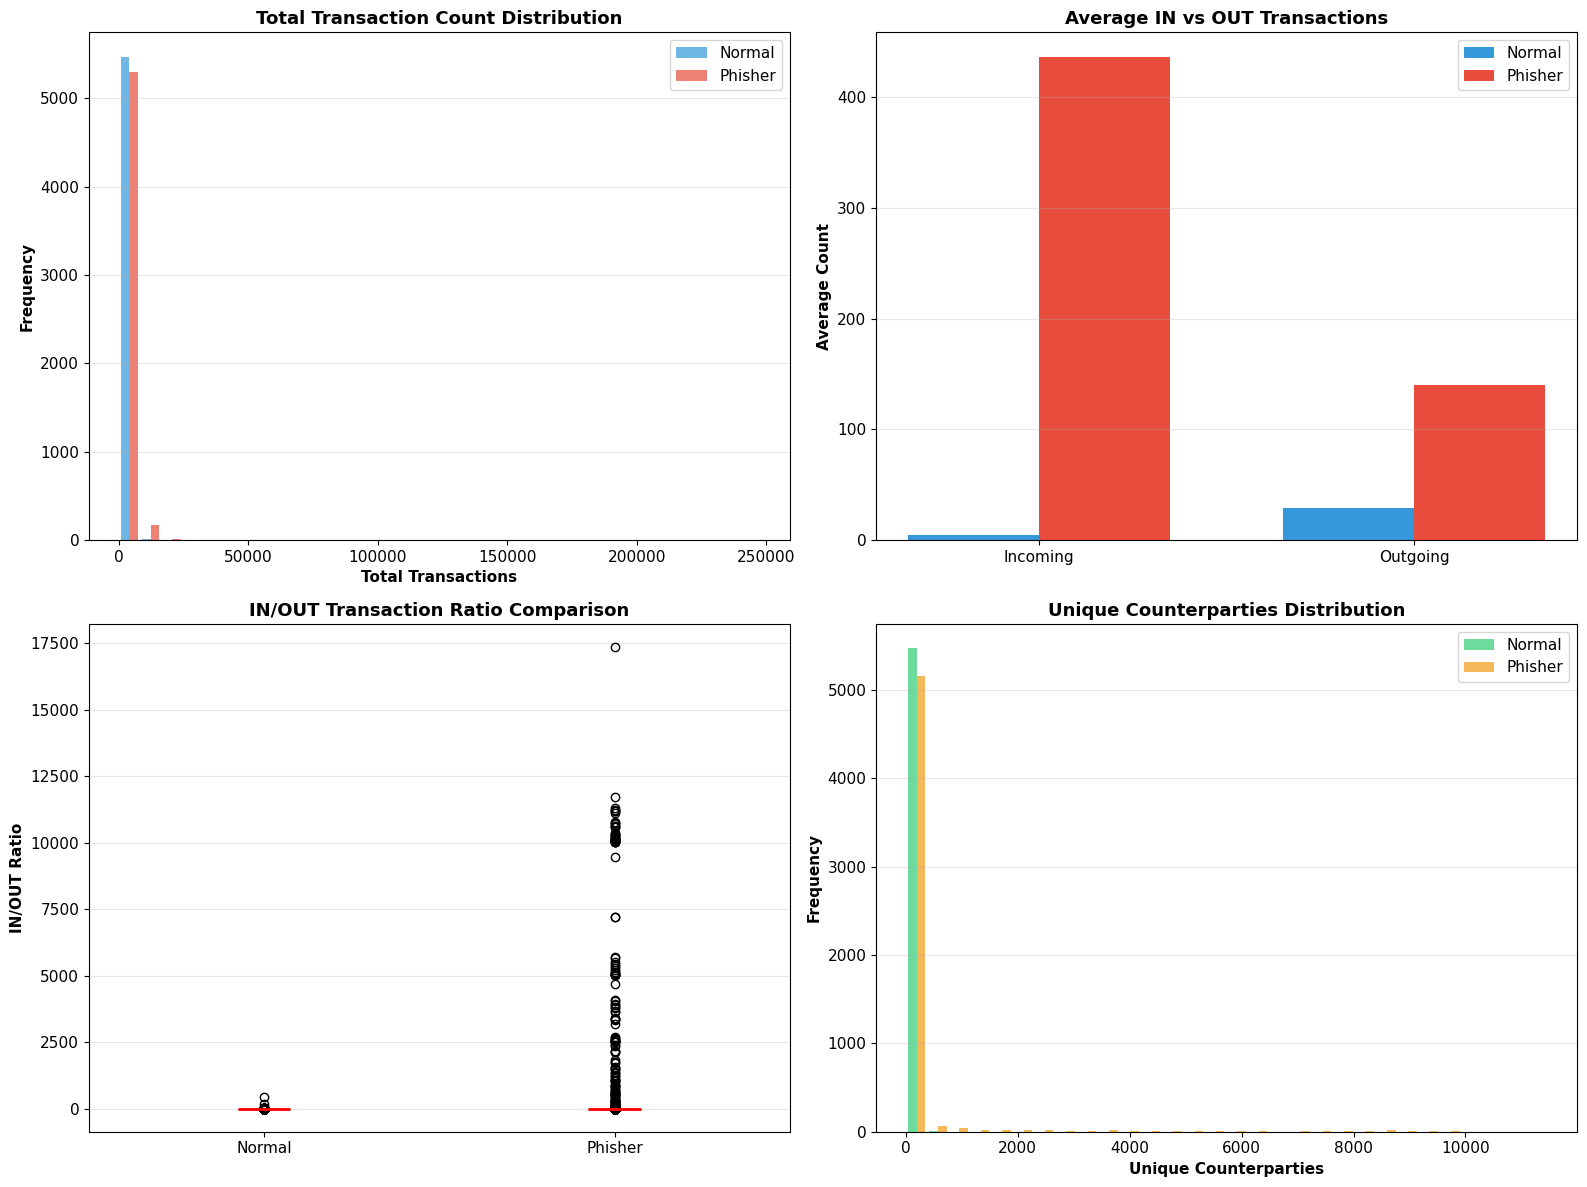

✅ Transaction comparison plot saved to: outputs/figures/03_transaction_comparison.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Total Transactions Distribution
axes[0, 0].hist([normal_df['total_transactions'], phisher_df['total_transactions']], 
               bins=30, label=['Normal', 'Phisher'], color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0, 0].set_xlabel('Total Transactions', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Total Transaction Count Distribution', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. IN vs OUT Transactions
in_out_data = pd.DataFrame({
    'Normal IN': [normal_df['in_transactions'].mean()],
    'Normal OUT': [normal_df['out_transactions'].mean()],
    'Phisher IN': [phisher_df['in_transactions'].mean()],
    'Phisher OUT': [phisher_df['out_transactions'].mean()]
})

x_pos = np.arange(2)
width = 0.35
axes[0, 1].bar(x_pos - width/2, [normal_df['in_transactions'].mean(), normal_df['out_transactions'].mean()],
              width, label='Normal', color='#3498db')
axes[0, 1].bar(x_pos + width/2, [phisher_df['in_transactions'].mean(), phisher_df['out_transactions'].mean()],
              width, label='Phisher', color='#e74c3c')
axes[0, 1].set_ylabel('Average Count', fontweight='bold')
axes[0, 1].set_title('Average IN vs OUT Transactions', fontsize=13, fontweight='bold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(['Incoming', 'Outgoing'])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. IN/OUT Ratio Comparison
axes[1, 0].boxplot([normal_df['in_out_ratio'], phisher_df['in_out_ratio']],
                   labels=['Normal', 'Phisher'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#95a5a6', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_ylabel('IN/OUT Ratio', fontweight='bold')
axes[1, 0].set_title('IN/OUT Transaction Ratio Comparison', fontsize=13, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Unique Counterparties
axes[1, 1].hist([normal_df['unique_counterparties'], phisher_df['unique_counterparties']],
               bins=30, label=['Normal', 'Phisher'], color=['#2ecc71', '#f39c12'], alpha=0.7)
axes[1, 1].set_xlabel('Unique Counterparties', fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontweight='bold')
axes[1, 1].set_title('Unique Counterparties Distribution', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/03_transaction_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Transaction comparison plot saved to: outputs/figures/03_transaction_comparison.png")

## 6. Visual Comparison: Transaction Amounts

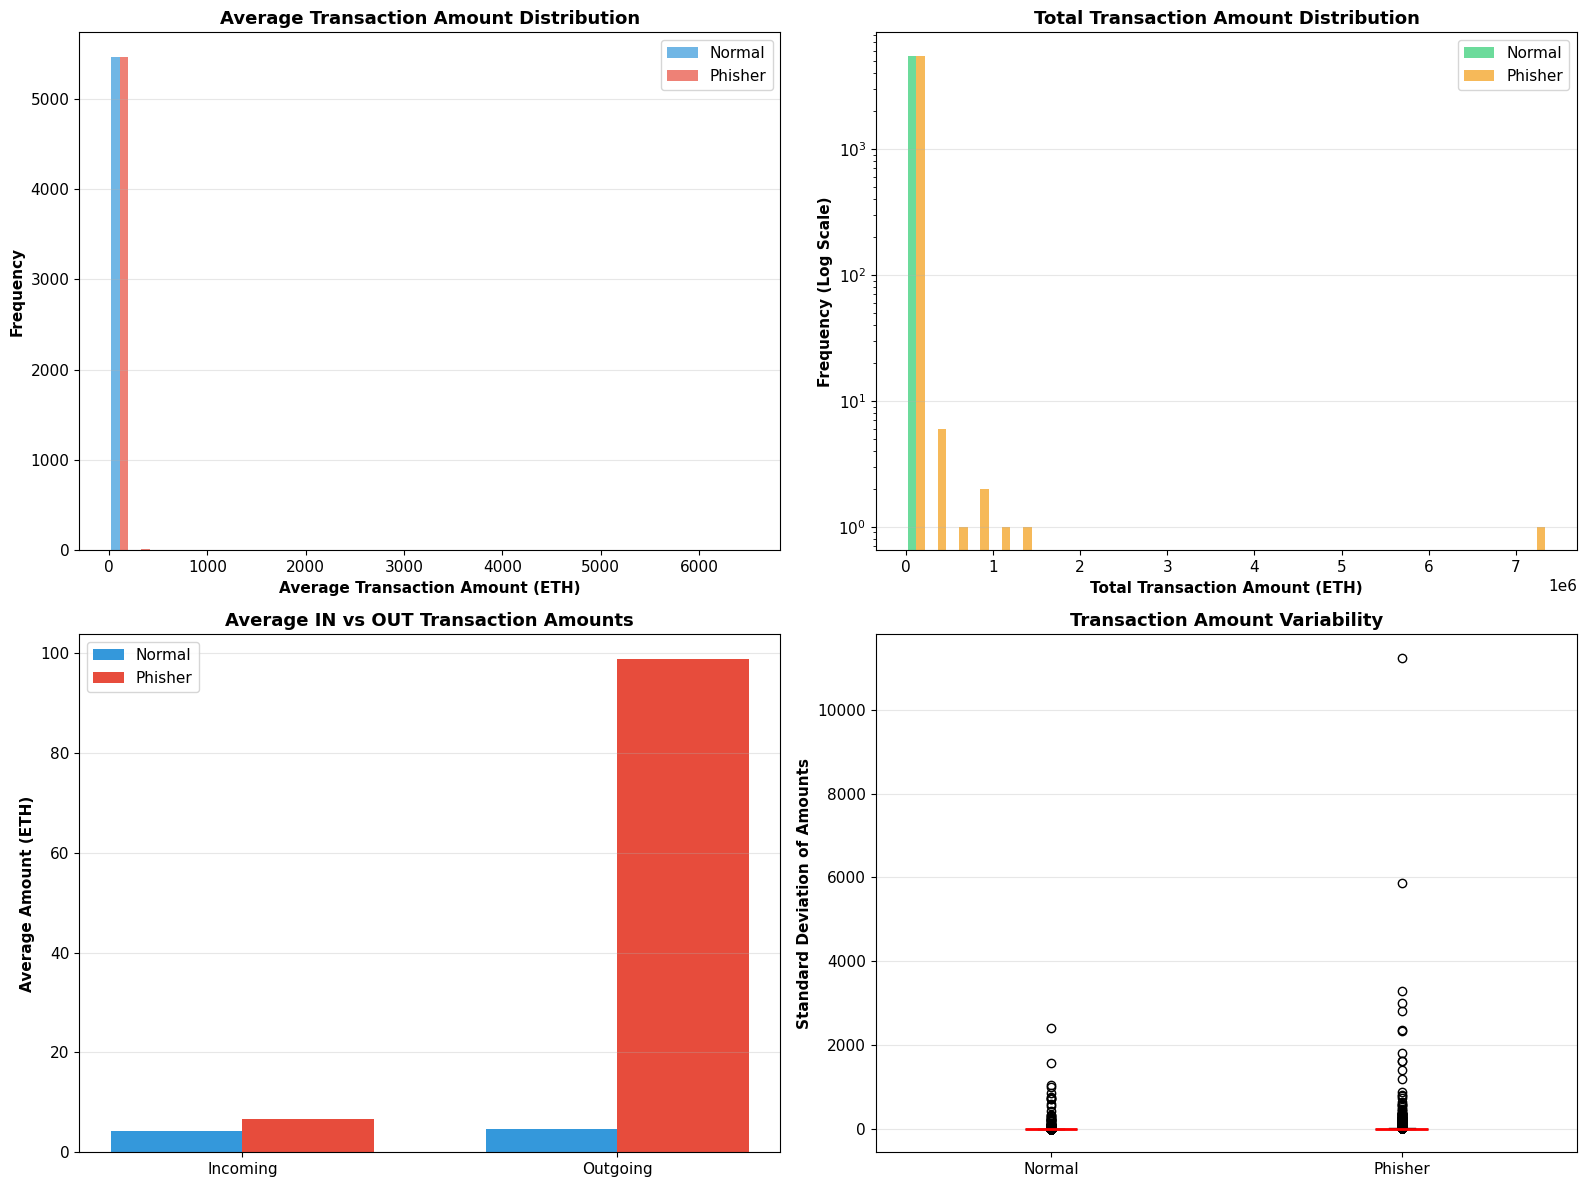

✅ Amount comparison plot saved to: outputs/figures/04_amount_comparison.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average Amount Distribution
axes[0, 0].hist([normal_df['avg_amount'], phisher_df['avg_amount']],
               bins=30, label=['Normal', 'Phisher'], color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0, 0].set_xlabel('Average Transaction Amount (ETH)', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Average Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Total Amount Comparison (Log Scale)
axes[0, 1].hist([normal_df['total_amount'], phisher_df['total_amount']],
               bins=30, label=['Normal', 'Phisher'], color=['#2ecc71', '#f39c12'], alpha=0.7)
axes[0, 1].set_xlabel('Total Transaction Amount (ETH)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency (Log Scale)', fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Total Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. IN vs OUT Amount Comparison
x_pos = np.arange(2)
width = 0.35
axes[1, 0].bar(x_pos - width/2, [normal_df['avg_in_amount'].mean(), normal_df['avg_out_amount'].mean()],
              width, label='Normal', color='#3498db')
axes[1, 0].bar(x_pos + width/2, [phisher_df['avg_in_amount'].mean(), phisher_df['avg_out_amount'].mean()],
              width, label='Phisher', color='#e74c3c')
axes[1, 0].set_ylabel('Average Amount (ETH)', fontweight='bold')
axes[1, 0].set_title('Average IN vs OUT Transaction Amounts', fontsize=13, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(['Incoming', 'Outgoing'])
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Amount Variability (Standard Deviation)
axes[1, 1].boxplot([normal_df['std_amount'], phisher_df['std_amount']],
                   labels=['Normal', 'Phisher'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#9b59b6', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Standard Deviation of Amounts', fontweight='bold')
axes[1, 1].set_title('Transaction Amount Variability', fontsize=13, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/04_amount_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Amount comparison plot saved to: outputs/figures/04_amount_comparison.png")

## 7. Temporal Behavior Analysis

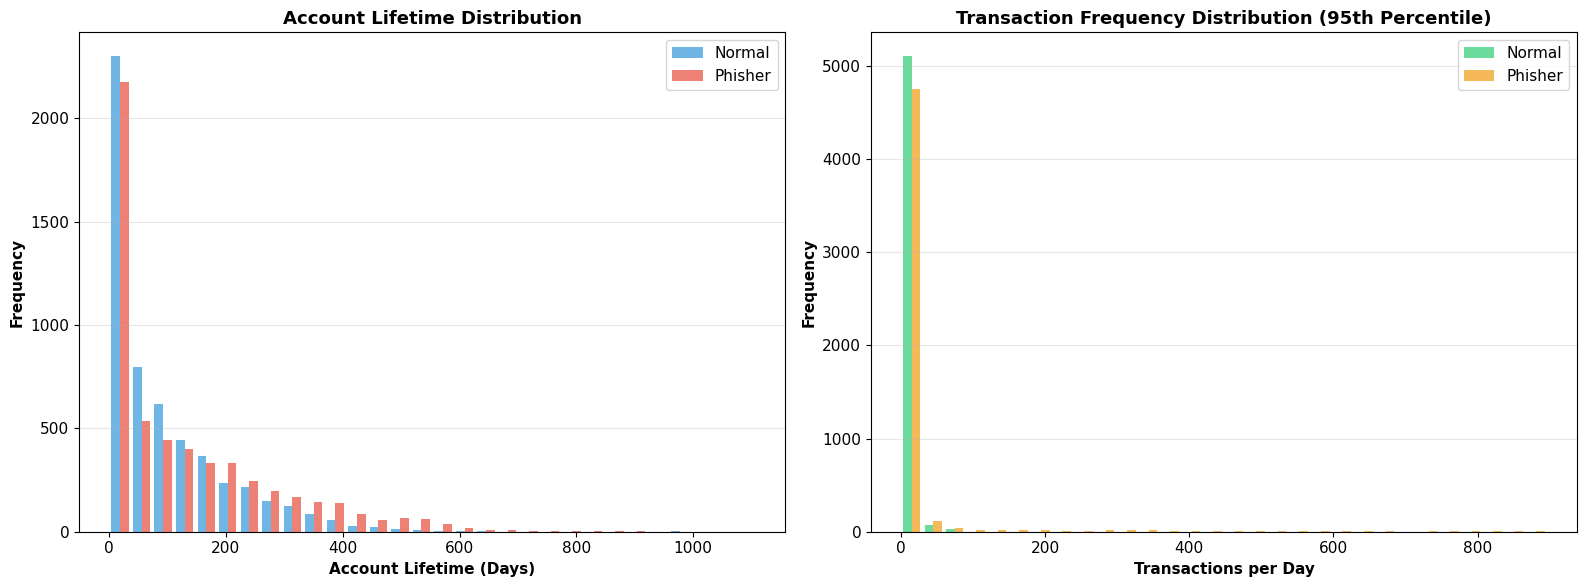

✅ Temporal comparison plot saved to: outputs/figures/05_temporal_comparison.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Account Lifetime (Time Span)
axes[0].hist([normal_df['time_span_days'], phisher_df['time_span_days']],
            bins=30, label=['Normal', 'Phisher'], color=['#3498db', '#e74c3c'], alpha=0.7)
axes[0].set_xlabel('Account Lifetime (Days)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Account Lifetime Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Transaction Frequency (Transactions per Day)
# Filter out extreme outliers for better visualization
normal_tx_rate = normal_df['tx_per_day'][normal_df['tx_per_day'] < normal_df['tx_per_day'].quantile(0.95)]
phisher_tx_rate = phisher_df['tx_per_day'][phisher_df['tx_per_day'] < phisher_df['tx_per_day'].quantile(0.95)]

axes[1].hist([normal_tx_rate, phisher_tx_rate],
            bins=30, label=['Normal', 'Phisher'], color=['#2ecc71', '#f39c12'], alpha=0.7)
axes[1].set_xlabel('Transactions per Day', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Transaction Frequency Distribution (95th Percentile)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/05_temporal_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Temporal comparison plot saved to: outputs/figures/05_temporal_comparison.png")

## 8. Correlation Analysis

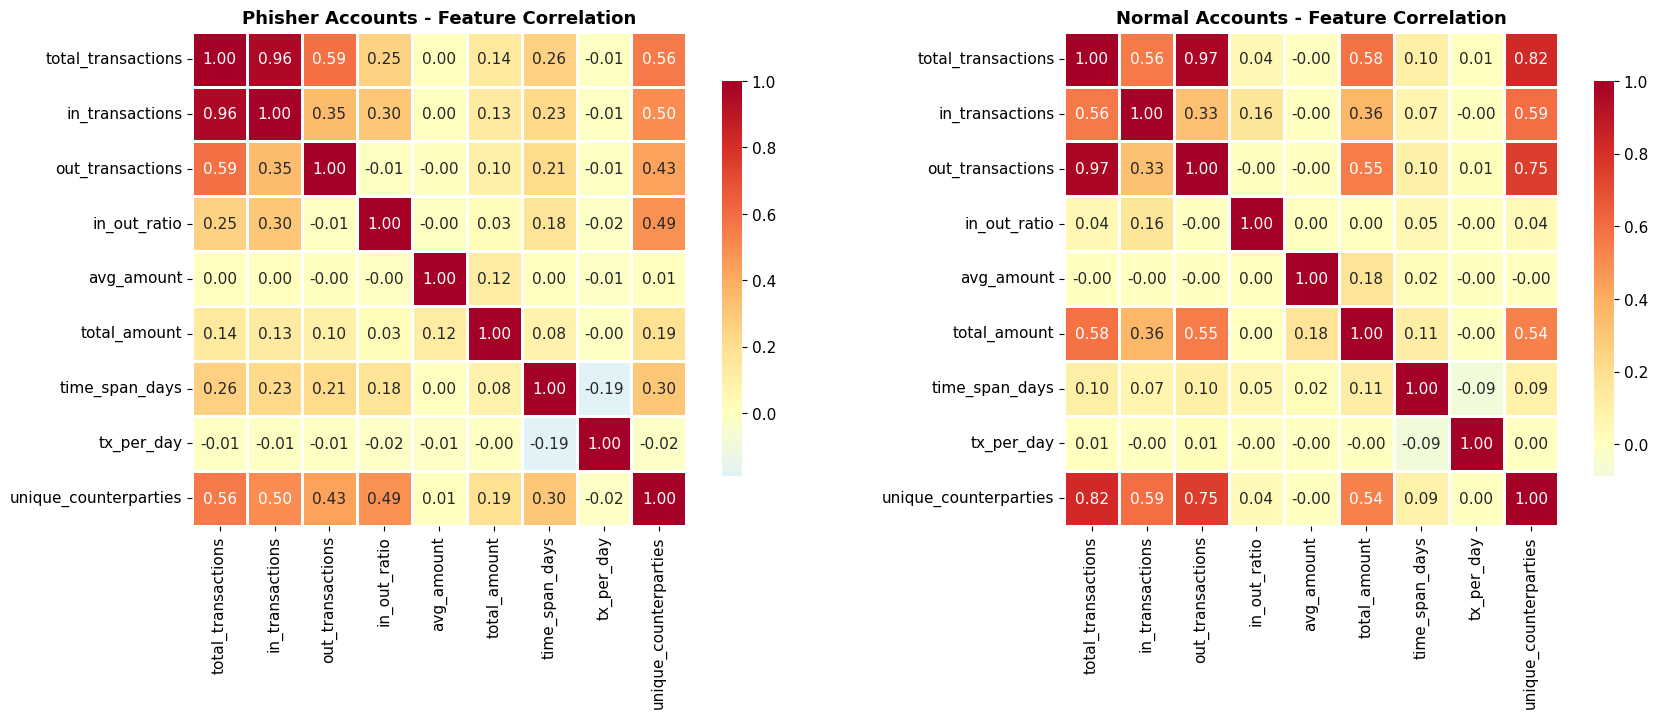

✅ Correlation analysis plot saved to: outputs/figures/06_correlation_analysis.png


In [8]:
# Select numeric features for correlation
numeric_features = [
    'total_transactions', 'in_transactions', 'out_transactions',
    'in_out_ratio', 'avg_amount', 'total_amount',
    'time_span_days', 'tx_per_day', 'unique_counterparties'
]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Phisher correlation
phisher_corr = phisher_df[numeric_features].corr()
sns.heatmap(phisher_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title('Phisher Accounts - Feature Correlation', fontsize=13, fontweight='bold')

# Normal correlation
normal_corr = normal_df[numeric_features].corr()
sns.heatmap(normal_corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title('Normal Accounts - Feature Correlation', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/06_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation analysis plot saved to: outputs/figures/06_correlation_analysis.png")

## 9. Key Insights Summary

In [9]:
# Calculate key differences
insights = []

# Transaction count difference
tx_diff = ((phisher_df['total_transactions'].mean() - normal_df['total_transactions'].mean()) / 
           normal_df['total_transactions'].mean() * 100)
insights.append(f"Phisher accounts have {abs(tx_diff):.1f}% {'more' if tx_diff > 0 else 'fewer'} transactions on average")

# Amount difference
amt_diff = ((phisher_df['avg_amount'].mean() - normal_df['avg_amount'].mean()) / 
            normal_df['avg_amount'].mean() * 100)
insights.append(f"Phisher accounts have {abs(amt_diff):.1f}% {'higher' if amt_diff > 0 else 'lower'} average transaction amounts")

# IN/OUT ratio difference
ratio_diff = ((phisher_df['in_out_ratio'].mean() - normal_df['in_out_ratio'].mean()) / 
              normal_df['in_out_ratio'].mean() * 100)
insights.append(f"Phisher accounts have {abs(ratio_diff):.1f}% {'higher' if ratio_diff > 0 else 'lower'} IN/OUT ratios")

# Transaction frequency
freq_diff = ((phisher_df['tx_per_day'].mean() - normal_df['tx_per_day'].mean()) / 
             normal_df['tx_per_day'].mean() * 100)
insights.append(f"Phisher accounts are {abs(freq_diff):.1f}% {'more' if freq_diff > 0 else 'less'} active (tx/day)")

# Unique counterparties
counter_diff = ((phisher_df['unique_counterparties'].mean() - normal_df['unique_counterparties'].mean()) / 
                normal_df['unique_counterparties'].mean() * 100)
insights.append(f"Phisher accounts interact with {abs(counter_diff):.1f}% {'more' if counter_diff > 0 else 'fewer'} unique addresses")

print("\n🔑 KEY INSIGHTS FROM COMPARATIVE ANALYSIS")
print("=" * 80)
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")
print("=" * 80)

# Save insights
insights_text = "\n".join([f"{i}. {insight}" for i, insight in enumerate(insights, 1)])
with open('../outputs/reports/02_key_insights.txt', 'w', encoding='utf-8') as f:
    f.write("KEY INSIGHTS FROM COMPARATIVE ANALYSIS\n")
    f.write("=" * 80 + "\n")
    f.write(insights_text)

print("\n✅ Key insights saved to: outputs/reports/02_key_insights.txt")


🔑 KEY INSIGHTS FROM COMPARATIVE ANALYSIS
1. Phisher accounts have 1649.8% more transactions on average
2. Phisher accounts have 0.2% higher average transaction amounts
3. Phisher accounts have 25337.9% higher IN/OUT ratios
4. Phisher accounts are 235.3% more active (tx/day)
5. Phisher accounts interact with 1618.4% more unique addresses

✅ Key insights saved to: outputs/reports/02_key_insights.txt


## 10. Export Detailed Comparison Data

In [10]:
# Save combined dataset for further analysis
combined_df.to_csv('../outputs/reports/02_detailed_comparison_data.csv', index=False)
print(f"✅ Detailed comparison data saved: {len(combined_df):,} accounts")
print(f"   - Phisher: {len(phisher_df):,}")
print(f"   - Normal: {len(normal_df):,}")
print("   - File: outputs/reports/02_detailed_comparison_data.csv")

✅ Detailed comparison data saved: 10,960 accounts
   - Phisher: 5,480
   - Normal: 5,480
   - File: outputs/reports/02_detailed_comparison_data.csv


## 📌 Conclusion

This comparative analysis has successfully:
1. ✅ Extracted comprehensive features from both phisher and normal accounts
2. ✅ Performed statistical comparisons across multiple dimensions
3. ✅ Visualized key differences in transaction patterns
4. ✅ Identified distinguishing characteristics of phisher accounts
5. ✅ Generated detailed comparison reports and datasets

**Key Findings:**
- Clear behavioral differences exist between phisher and normal accounts
- Transaction patterns, amounts, and temporal behavior show distinct signatures
- These features can be leveraged for machine learning classification

**Next Steps:**
- Proceed to `03_storytelling_visuals.ipynb` for narrative-driven visualizations
- Use insights to guide feature selection for ML models
- Demonstrate impact of data preparation on model performance